Raw data
   ↓
General cleaning
   ├── Fix data types
   ├── Standardize categories
   ├── Remove duplicates
   ├── Remove clearly invalid values
   ├── Handle obvious formatting problems
   └── Preserve meaningful missing values
              ↓
       Cleaned master data
          /          \
         /            \
   Dashboard          ML
                       ↓
               Model-specific
                preprocessing
                       ↓
              Imputation/encoding/
                  scaling/etc.

In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import json

## Data Overview

In [4]:
# Replace 'file.csv' with your CSV file's path
df = pd.read_csv('../data/listings.csv')

# Display the first few rows
df.head()

C:\Users\YapJack\AppData\Local\Temp\ipykernel_31672\547028398.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/listings.csv')


,id,name,host_id,host_name,host_since,host_response_time,host_response_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,...,bathrooms,bedrooms,beds,price,minimum_nights,availability_365,number_of_reviews,review_scores_rating,license,instant_bookable
0,670339032744709144,Westwood lovely three bedrooms three bathrooms,4780152,Moon,20/01/13,within a few hours,0.96,f,West Los Angeles,City of Los Angeles,...,3.0,3.0,3.0,399.0,30,365,0,NaN,NaN,f
1,37014494,Spanish style lower duplex near Beverly Hills,278288178,Ida,22/07/19,NaN,NaN,f,Beverlywood,City of Los Angeles,...,NaN,2.0,NaN,NaN,30,0,0,NaN,NaN,f
2,1024835174766068422,Charming Beverly Hills Home,513813179,Tiana,08/05/23,within a day,0.60,f,Beverly Hills,Other Cities,...,3.0,3.0,3.0,434.0,30,267,0,NaN,NaN,f
3,850744632375448560,Tianpu's warm room with bathroom,432956623,Dan,22/11/21,a few days or more,0.20,f,Temple City,Other Cities,...,1.0,1.0,1.0,49.0,1,364,1,3.00,NaN,f
4,953950676345326970,"Santa Monica apt, free parking, steps to the b...",528669205,Farkhat,29/07/23,within an hour,1.00,t,Santa Monica,Other Cities,...,1.0,0.0,1.0,231.0,5,193,44,4.93,Exempt,t


In [5]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'host_since',
       'host_response_time', 'host_response_rate', 'host_is_superhost',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'price', 'minimum_nights', 'availability_365',
       'number_of_reviews', 'review_scores_rating', 'license',
       'instant_bookable'],
      dtype='object')

In [6]:
print('Number of rows:' )
df.shape

Number of rows:


(45530, 25)

In [7]:
# Numerical Summary
df.describe()

,id,host_id,host_response_rate,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,availability_365,number_of_reviews,review_scores_rating
count,4.553000e+04,4.553000e+04,35443.000000,45530.000000,45530.000000,45530.000000,37291.000000,42491.000000,37196.000000,37293.000000,45530.000000,45530.000000,45530.000000,33385.000000
mean,5.208642e+17,1.950367e+08,0.952007,34.055299,-118.312754,4.019613,1.647918,1.785508,2.253226,287.844287,17.858972,195.091720,36.661212,4.778774
std,4.976588e+17,1.899734e+08,0.168672,0.141390,0.172192,2.861154,1.191748,1.318149,1.777228,653.643044,28.836791,133.393743,80.550690,0.415014
min,1.090000e+02,5.210000e+02,0.000000,33.338360,-118.917134,1.000000,0.000000,0.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000
25%,3.319470e+07,2.632699e+07,1.000000,33.998590,-118.413105,2.000000,1.000000,1.000000,1.000000,98.000000,2.000000,75.000000,0.000000,4.730000
50%,6.362901e+17,1.165605e+08,1.000000,34.060623,-118.343396,3.000000,1.000000,1.000000,2.000000,155.000000,14.000000,202.000000,6.000000,4.900000
75%,1.006570e+18,3.712308e+08,1.000000,34.108151,-118.233740,6.000000,2.000000,2.000000,3.000000,260.000000,30.000000,335.000000,34.000000,5.000000
max,1.238217e+18,5.997497e+08,1.000000,34.811183,-117.653352,16.000000,24.000000,24.000000,32.000000,21569.000000,1124.000000,365.000000,3024.000000,5.000000


In [8]:
# Categorical Summary
df.describe(include=object)

,name,host_name,host_since,host_response_time,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,property_type,room_type,license,instant_bookable
count,45529,45528,45528,35443,44278,45530,45530,45530,45530,12803,45530
unique,44001,8631,11930,4,2,266,3,103,4,7582,2
top,Home away from home,Blueground,16/12/16,within an hour,f,Long Beach,City of Los Angeles,Entire home,Entire home/apt,Exempt,f
freq,18,569,239,27620,27610,1853,22446,12390,33610,1204,33798


In [9]:
df.dtypes

id                                int64
name                             object
host_id                           int64
host_name                        object
host_since                       object
host_response_time               object
host_response_rate              float64
host_is_superhost                object
neighbourhood_cleansed           object
neighbourhood_group_cleansed     object
latitude                        float64
longitude                       float64
property_type                    object
room_type                        object
accommodates                      int64
bathrooms                       float64
bedrooms                        float64
beds                            float64
price                           float64
minimum_nights                    int64
availability_365                  int64
number_of_reviews                 int64
review_scores_rating            float64
license                          object
instant_bookable                 object


In [10]:
df['neighbourhood_group_cleansed'].unique()

array(['City of Los Angeles', 'Other Cities', 'Unincorporated Areas'],
      dtype=object)

In [11]:
neighbourhood_table = (
    df[['neighbourhood_group_cleansed', 'neighbourhood_cleansed']]
    .drop_duplicates()
    .sort_values(['neighbourhood_group_cleansed', 'neighbourhood_cleansed'])
)

neighbourhood_table

,neighbourhood_group_cleansed,neighbourhood_cleansed
363,City of Los Angeles,Adams-Normandie
18793,City of Los Angeles,Arleta
1019,City of Los Angeles,Arlington Heights
915,City of Los Angeles,Atwater Village
1799,City of Los Angeles,Baldwin Hills/Crenshaw
...,...,...
2923,Unincorporated Areas,West Compton
5964,Unincorporated Areas,West Puente Valley
2070,Unincorporated Areas,West Whittier-Los Nietos
920,Unincorporated Areas,Westmont


In [12]:
neighbourhood_mapping = (
    df[['neighbourhood_group_cleansed', 'neighbourhood_cleansed']]
    .drop_duplicates()
    .sort_values([
        'neighbourhood_group_cleansed',
        'neighbourhood_cleansed'
    ])
    .groupby('neighbourhood_group_cleansed')['neighbourhood_cleansed']
    .apply(list)
    .to_dict()
)

with open('neighbourhood_mapping.json', 'w', encoding='utf-8') as f:
    json.dump(neighbourhood_mapping, f, indent=4, ensure_ascii=False)

In [13]:
dupes = (
    neighbourhood_table
    .groupby('neighbourhood_cleansed')['neighbourhood_group_cleansed']
    .nunique()
)

dupes[dupes > 1]

Series([], Name: neighbourhood_group_cleansed, dtype: int64)

In [14]:
df_cleaned = df.copy()

## Fix Data Type

We first address the data type of host_since, which is currently stored as an object but should be represented as a datetime field for accurate date-based analysis.

In [15]:
# df_cleaned["host_since"] = pd.to_datetime(
#     df_cleaned["host_since"], errors="coerce"
# ).dt.normalize()
# print(df_cleaned["host_since"].dtype)

## Duplicate Handling

In [16]:
# print("Duplicates:", df_cleaned.duplicated().sum())

In [17]:
df_cleaned = df_cleaned.drop_duplicates()

## Null Handling

In [18]:
df_cleaned.isnull().sum()

id                                  0
name                                1
host_id                             0
host_name                           2
host_since                          2
host_response_time              10087
host_response_rate              10087
host_is_superhost                1252
neighbourhood_cleansed              0
neighbourhood_group_cleansed        0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bathrooms                        8239
bedrooms                         3039
beds                             8334
price                            8237
minimum_nights                      0
availability_365                    0
number_of_reviews                   0
review_scores_rating            12145
license                         32727
instant_bookable                    0
dtype: int64

In [19]:
df_cleaned["host_is_superhost"].value_counts(dropna=False)

host_is_superhost
f      27610
t      16668
NaN     1252
Name: count, dtype: int64

In [20]:
df_cleaned = df_cleaned[df_cleaned["price"].notnull()]
df_cleaned = df_cleaned[df_cleaned["beds"].notnull()]
df_cleaned = df_cleaned[df_cleaned["bedrooms"].notnull()]
df_cleaned = df_cleaned[df_cleaned["bathrooms"].notnull()]

In [21]:
df_cleaned.isnull().sum()

id                                  0
name                                0
host_id                             0
host_name                           0
host_since                          0
host_response_time               4226
host_response_rate               4226
host_is_superhost                1152
neighbourhood_cleansed              0
neighbourhood_group_cleansed        0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bathrooms                           0
bedrooms                            0
beds                                0
price                               0
minimum_nights                      0
availability_365                    0
number_of_reviews                   0
review_scores_rating             8988
license                         25760
instant_bookable                    0
dtype: int64

## Standardize Values

Check leading/trailing whitespace

In [22]:
categorical_cols = df_cleaned.select_dtypes(include=["object", "string", "category"]).columns

for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].astype("string").str.strip()

In [23]:
categorical_cols = df_cleaned.select_dtypes(include=["string"]).columns

for col in categorical_cols:
    count = df_cleaned[col].astype("string").str.strip().ne(
        df_cleaned[col].astype("string")
    ).sum()
    
    if count > 0:
        print(f"{col}: {count} values have leading/trailing whitespace")

check whether neighbourhood_cleansed is normalized

In [24]:
pd.set_option('display.max_seq_items', None)

# print(df_cleaned["neighbourhood_cleansed"].unique())

In [25]:
df_cleaned["neighbourhood_cleansed"].str.lower().nunique()

265

Compared the unique values after converting them to lowercase against the original values. No differences were identified, indicating that there are no casing inconsistencies in the column.


In [26]:
pd.set_option('display.max_seq_items', None)

# print(df_cleaned["property_type"].unique())

The property_type column does not have significant formatting inconsistencies, but it contains a large number of categories with overlapping structures, such as Entire condo, Private room in condo, and Shared room in condo.

Further normalization may therefore be beneficial. Alternatively, the column could be addressed through feature engineering by separating the accommodation arrangement (e.g., Entire, Private room, Shared room) from the underlying property type (e.g., Condo, Villa, Townhouse). This would reduce category complexity and provide more meaningful features for analysis and machine learning.

In [27]:
df_cleaned['price_per_night'] = (
    df_cleaned['price'] / df_cleaned['minimum_nights']
)

## Drop Initially Unavailable Attributes 

Certain columns will be excluded because the project's objective is to develop a price calculator for new Airbnb hosts. Therefore, the model should only use attributes that are available at the initial listing-planning stage, rather than information that becomes available after the listing has been published, such as reviews, ratings, or historical performance.

In [28]:
df_cleaned = df_cleaned.drop(columns=['id', 'name', 'host_id', 'host_name', 'host_since',
                                 'host_response_time', 'host_response_rate', 
                                 'number_of_reviews', 'review_scores_rating', 'license'])

In [29]:

categorical_cols = [
    "property_type",
    "neighbourhood_group_cleansed",
    "neighbourhood_cleansed",
    "room_type",
]

# Split
train_df, test_df = train_test_split(
    df_cleaned,
    test_size=0.20,
    random_state=42
)

# Keep only test rows whose categories exist in training
for col in categorical_cols:
    train_categories = set(train_df[col].dropna().unique())

    test_df = test_df[
        test_df[col].isin(train_categories)
    ]

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 29624
Test: 7405


In [30]:
print("Train:")
print(train_df["host_is_superhost"].value_counts())

print("\nTest:")
print(test_df["host_is_superhost"].value_counts())

Train:
host_is_superhost
f    16193
t    12496
Name: count, dtype: Int64

Test:
host_is_superhost
f    3986
t    3202
Name: count, dtype: Int64


In [31]:
train_df["host_is_superhost"] = train_df["host_is_superhost"].fillna("f")
test_df["host_is_superhost"] = test_df["host_is_superhost"].fillna("f")

## Invalid Values

In [32]:
# Numerical Summary
df.describe()

,id,host_id,host_response_rate,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,availability_365,number_of_reviews,review_scores_rating
count,4.553000e+04,4.553000e+04,35443.000000,45530.000000,45530.000000,45530.000000,37291.000000,42491.000000,37196.000000,37293.000000,45530.000000,45530.000000,45530.000000,33385.000000
mean,5.208642e+17,1.950367e+08,0.952007,34.055299,-118.312754,4.019613,1.647918,1.785508,2.253226,287.844287,17.858972,195.091720,36.661212,4.778774
std,4.976588e+17,1.899734e+08,0.168672,0.141390,0.172192,2.861154,1.191748,1.318149,1.777228,653.643044,28.836791,133.393743,80.550690,0.415014
min,1.090000e+02,5.210000e+02,0.000000,33.338360,-118.917134,1.000000,0.000000,0.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000
25%,3.319470e+07,2.632699e+07,1.000000,33.998590,-118.413105,2.000000,1.000000,1.000000,1.000000,98.000000,2.000000,75.000000,0.000000,4.730000
50%,6.362901e+17,1.165605e+08,1.000000,34.060623,-118.343396,3.000000,1.000000,1.000000,2.000000,155.000000,14.000000,202.000000,6.000000,4.900000
75%,1.006570e+18,3.712308e+08,1.000000,34.108151,-118.233740,6.000000,2.000000,2.000000,3.000000,260.000000,30.000000,335.000000,34.000000,5.000000
max,1.238217e+18,5.997497e+08,1.000000,34.811183,-117.653352,16.000000,24.000000,24.000000,32.000000,21569.000000,1124.000000,365.000000,3024.000000,5.000000


### `Price`

All values in the price column should be greater than zero. Values less than or equal to zero were checked and should be investigated as invalid records.

In [33]:
(df_cleaned["price"] > 0).all()

np.True_

### `beds`

The `beds` column contains records with a value of `0`. These values should not be automatically classified as invalid, as a listing may legitimately have no reported beds depending on the accommodation type or furnishing arrangement. Therefore, the zero values are retained unless further analysis identifies them as inconsistent with other listing attributes.


In [34]:
print((df_cleaned["beds"] > 0).all())

print(f"num of beds less than 1: {(df_cleaned["beds"] <= 0).sum()}")

False
num of beds less than 1: 797


In [35]:
df_cleaned[df_cleaned["beds"] <= 0]

,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,availability_365,instant_bookable,price_per_night
132,t,Hollywood,City of Los Angeles,34.086919,-118.336080,Entire home,Entire home/apt,8,4.0,4.0,0.0,479.0,3,269,f,159.666667
195,f,Monterey Park,Other Cities,34.056750,-118.117865,Shared room in home,Shared room,1,1.0,1.0,0.0,28.0,1,170,f,28.000000
226,f,Fairfax,City of Los Angeles,34.081916,-118.352693,Entire home,Entire home/apt,2,1.0,1.0,0.0,119.0,30,176,f,3.966667
257,f,Venice,City of Los Angeles,33.995940,-118.478710,Entire guest suite,Entire home/apt,1,1.0,1.0,0.0,80.0,30,365,f,2.666667
259,t,Beverly Hills,Other Cities,34.067665,-118.385777,Entire home,Entire home/apt,8,4.0,4.0,0.0,462.0,1,206,f,462.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44905,f,West Hollywood,Other Cities,34.091420,-118.343700,Entire home,Entire home/apt,7,2.0,3.0,0.0,301.0,2,90,t,150.500000
45169,t,Pico-Union,City of Los Angeles,34.047633,-118.298992,Private room in home,Private room,1,1.5,1.0,0.0,36.0,30,78,f,1.200000
45262,t,Silver Lake,City of Los Angeles,34.085230,-118.270880,Entire rental unit,Entire home/apt,2,1.0,1.0,0.0,207.0,30,308,f,6.900000
45275,f,Sawtelle,City of Los Angeles,34.022561,-118.441532,Entire home,Entire home/apt,2,1.0,1.0,0.0,98.0,30,270,f,3.266667


### `bedrooms`

The `beds` column contains records with a value of `0`. These values should not be automatically classified as invalid, as a listing may legitimately have no reported beds depending on the accommodation type or furnishing arrangement. Therefore, the zero values are retained unless further analysis identifies them as inconsistent with other listing attributes.


In [36]:
print((df_cleaned["bedrooms"] > 0).all())

print(f"num of beds less than 1: {(df_cleaned["bedrooms"] <= 0).sum()}")

False
num of beds less than 1: 2789


## Anomaly Detection

We first examined the distribution of price using descriptive statistics and several percentiles, histogram, and boxplot. This allowed us to understand the typical price range and identify unusually low or high values before investigating potential anomalies.



In [37]:
df_cleaned["price_per_night"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

count    37031.000000
mean       101.901455
std        373.916556
min          0.117143
1%           1.000000
5%           1.833333
25%          4.833333
50%         34.500000
75%        115.000000
95%        333.000000
99%        948.400000
max      21569.000000
Name: price_per_night, dtype: float64

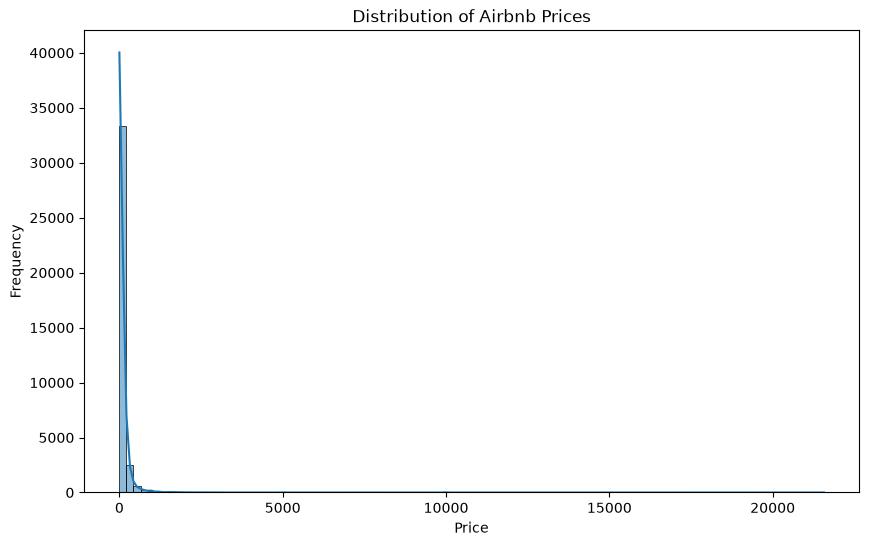

In [38]:

plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned["price_per_night"], bins=100, kde=True)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

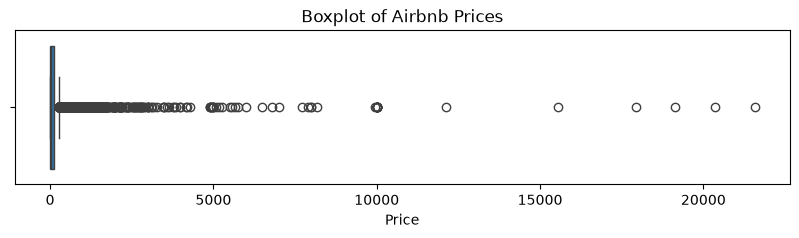

In [39]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=df_cleaned["price_per_night"])

plt.title("Boxplot of Airbnb Prices")
plt.xlabel("Price")

plt.show()

In [40]:
df_cleaned.columns

Index(['host_is_superhost', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'price', 'minimum_nights', 'availability_365',
       'instant_bookable', 'price_per_night'],
      dtype='object')

In [41]:
columns = [ 
    'neighbourhood_cleansed',
    'neighbourhood_group_cleansed',
    'latitude',
    'longitude',
    'property_type',
    'room_type',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'price',
    'minimum_nights',
    'price_per_night',
    'availability_365',
]


In [42]:
extreme_outlier = df_cleaned[df_cleaned['price_per_night'] > 948.400000]
extreme_outlier[columns].head(20)

,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,price_per_night,availability_365
251,Venice,City of Los Angeles,33.984623,-118.471613,Entire home,Entire home/apt,8,3.5,4.0,4.0,3000.0,1,3000.000000,365
389,Malibu,Other Cities,34.033598,-118.744472,Entire home,Entire home/apt,10,6.0,4.0,5.0,3371.0,2,1685.500000,83
500,Pasadena,Other Cities,34.145360,-118.169740,Entire villa,Entire home/apt,8,4.0,4.0,5.0,2642.0,2,1321.000000,363
502,Pasadena,Other Cities,34.165900,-118.174650,Entire home,Entire home/apt,6,2.5,3.0,3.0,5475.0,2,2737.500000,365
585,Altadena,Unincorporated Areas,34.174640,-118.098690,Entire home,Entire home/apt,16,0.0,0.0,1.0,2500.0,1,2500.000000,365
674,Santa Clarita,Other Cities,34.465840,-118.547900,Entire home,Entire home/apt,2,1.5,2.0,2.0,1400.0,1,1400.000000,269
813,Rowland Heights,Unincorporated Areas,33.991620,-117.887178,Private room in home,Private room,4,2.0,2.0,2.0,1390.0,1,1390.000000,151
867,West Covina,Other Cities,34.009590,-117.878390,Entire home,Entire home/apt,5,3.0,3.0,3.0,1600.0,1,1600.000000,269
1411,Manhattan Beach,Other Cities,33.900886,-118.418502,Entire condo,Entire home/apt,8,2.5,4.0,8.0,1429.0,1,1429.000000,343
1501,Hermosa Beach,Other Cities,33.863020,-118.400310,Shared room in bed and breakfast,Shared room,1,1.0,1.0,6.0,999.0,1,999.000000,364


### `High-price listings (> $2,500)`

1. price: Total price based on minimum nights required for booking.

Several listings have unusually high prices. However, their names and location indicate that they are luxury properties, which provides a reasonable explanation for the higher prices.

Some listings also require a minimum stay of 30 days, meaning the high price is associated with a monthly stay rather than a typical one-night booking. Although these prices appear extreme, we found no clear evidence of data-entry errors or invalid listings. Therefore, we retained these observations as potentially valid rather than removing them as outliers.

For example, a listing priced at $3,500 per night with a 30-night minimum stay would imply a very large total booking cost, but this alone does not prove that the underlying data is incorrect.

In [43]:
df_cleaned[columns].sort_values(by = 'price', ascending = True).head(30)

,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,price_per_night,availability_365
28335,Cypress Park,City of Los Angeles,34.088400,-118.213170,Entire home,Entire home/apt,2,1.0,1.0,1.0,5.0,30,0.166667,67
6288,Mid-City,City of Los Angeles,34.039076,-118.379462,Private room in rental unit,Private room,2,1.0,1.0,1.0,10.0,30,0.333333,180
22092,Long Beach,Other Cities,33.777060,-118.195370,Private room in home,Private room,1,1.0,1.0,1.0,10.0,1,10.000000,119
6158,Mid-City,City of Los Angeles,34.038469,-118.381285,Private room in rental unit,Private room,2,1.0,1.0,1.0,10.0,30,0.333333,151
25463,Playa del Rey,City of Los Angeles,33.952300,-118.450350,Entire condo,Entire home/apt,5,2.0,2.0,4.0,10.0,14,0.714286,193
37196,Hollywood,City of Los Angeles,34.104867,-118.314828,Private room in rental unit,Private room,2,1.0,1.0,1.0,10.0,30,0.333333,180
25676,Mid-City,City of Los Angeles,34.038790,-118.379350,Private room in rental unit,Private room,2,1.0,1.0,1.0,10.0,30,0.333333,180
3906,West Adams,City of Los Angeles,34.031330,-118.345220,Entire home,Entire home/apt,6,1.0,2.0,3.0,10.0,31,0.322581,94
28483,Pico-Union,City of Los Angeles,34.047932,-118.287308,Private room in home,Private room,2,3.0,1.0,1.0,10.0,30,0.333333,244
21863,Broadway-Manchester,City of Los Angeles,33.945870,-118.275830,Private room in home,Private room,2,3.0,1.0,1.0,10.0,30,0.333333,42


Conversely, extremely low prices were also identified. For example, a listing with a total price of $5 and a minimum stay of 30 days corresponds to an effective nightly price of approximately 0.17 per night. This was considered highly suspicious because the implied nightly price is exceptionally low and may indicate a data-entry or data-extraction error.

In [44]:
extreme_low = df_cleaned[df_cleaned['price_per_night'] < 1]
# len(extreme_low)
print(f"room_type distribution: {extreme_low['room_type'].value_counts()}")

room_type distribution: room_type
Shared room        159
Private room       132
Entire home/apt     64
Name: count, dtype: Int64


Extremely Low Effective Nightly Prices:
Listings with an effective nightly price below $1 were investigated based on room type. Such prices were considered particularly suspicious for private rooms and entire homes/apartments because the guest is paying for a private accommodation space. Shared-room listings were treated separately, as the lower level of accommodation provided may provide some context for a lower price. Private-room and entire-home listings that remained highly implausible after contextual review were removed as potential data-quality errors.

In [45]:
extreme_low_home = df_cleaned[
    (df_cleaned['price_per_night'] < 1) &
    (df_cleaned['room_type'].isin(['Entire home/apt']))
]
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

extreme_low_home[columns]


,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,price_per_night,availability_365
105,Beverly Hills,Other Cities,34.075158,-118.391097,Entire condo,Entire home/apt,4,2.0,2.0,3.0,175.0,181,0.966851,364
529,El Segundo,Other Cities,33.924350,-118.398510,Entire townhouse,Entire home/apt,4,2.5,3.0,3.0,175.0,180,0.972222,363
653,Westlake,City of Los Angeles,34.053767,-118.279137,Entire loft,Entire home/apt,6,1.0,1.0,1.0,18.0,30,0.600000,254
963,Glendale,Other Cities,34.154106,-118.251296,Entire rental unit,Entire home/apt,2,2.0,2.0,1.0,169.0,180,0.938889,358
1658,Studio City,City of Los Angeles,34.141750,-118.371900,Entire rental unit,Entire home/apt,4,2.0,2.0,2.0,130.0,150,0.866667,365
2638,Playa Vista,City of Los Angeles,33.974920,-118.421670,Entire condo,Entire home/apt,6,2.0,2.0,2.0,106.0,120,0.883333,180
3449,Venice,City of Los Angeles,33.996570,-118.462210,Entire home,Entire home/apt,2,1.0,1.0,2.0,115.0,175,0.657143,248
3503,West Hollywood,Other Cities,34.088640,-118.357970,Entire rental unit,Entire home/apt,4,2.0,2.0,2.0,150.0,365,0.410959,365
3906,West Adams,City of Los Angeles,34.031330,-118.345220,Entire home,Entire home/apt,6,1.0,2.0,3.0,10.0,31,0.322581,94
4164,Santa Monica,Other Cities,34.032460,-118.471130,Entire rental unit,Entire home/apt,1,1.0,1.0,1.0,90.0,365,0.246575,365


In [46]:
percentage = (
    (extreme_low_home['minimum_nights'] > 100).mean() * 100
)

print(f"{percentage:.2f}%")

71.88%


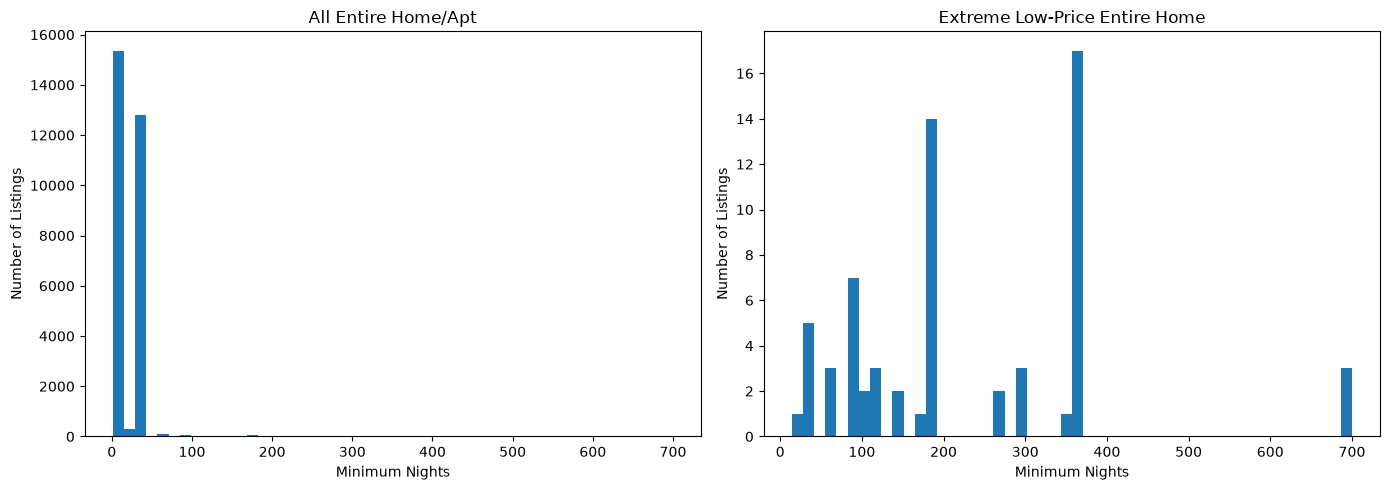

In [47]:
entire_home = df_cleaned[
    df_cleaned['room_type'] == 'Entire home/apt'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All Entire Home/Apt
axes[0].hist(entire_home['minimum_nights'], bins=50)
axes[0].set_xlabel('Minimum Nights')
axes[0].set_ylabel('Number of Listings')
axes[0].set_title('All Entire Home/Apt')

# Extreme Low-Price Entire Home
axes[1].hist(extreme_low_home['minimum_nights'], bins=50)
axes[1].set_xlabel('Minimum Nights')
axes[1].set_ylabel('Number of Listings')
axes[1].set_title('Extreme Low-Price Entire Home')

plt.tight_layout()
plt.show()

### `Extreme Low-Price Entire Home/Apt Listings`

The comparison shows that extreme low-price listings have substantially longer minimum-stay requirements than the overall Entire Home/Apt listings, with many requiring approximately 180, 360, or more nights. This suggests that some of the unusually low price_per_night values may be associated with long-term rental arrangements.

However, the total prices of some listings remain unrealistically low even after accounting for the long minimum stay. For example, a listing priced at 175 with a 180-night minimum stay would correspond to less than 1 per night for an entire home. Such prices are considered highly suspicious and unlikely to represent realistic accommodation prices.

After reviewing these observations and considering the minimum stay and room type, listings with extremely low prices that could not be reasonably explained by the available information were removed from the dataset.

In [48]:
df_extreme_cleaned = df_cleaned.drop(index=extreme_low_home.index).copy()

In [49]:
extreme_low_room = df_cleaned[
    (df_cleaned['price_per_night'] < 1) &
    (df_cleaned['room_type'].isin(['Private room']))
]
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

extreme_low_room[columns].sort_values(by = 'price_per_night', ascending=True)

,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,price_per_night,availability_365
28179,Calabasas,Other Cities,34.142200,-118.617560,Private room in home,Private room,1,1.0,1.0,1.0,41.0,350,0.117143,364
19397,West Hollywood,Other Cities,34.078240,-118.382170,Private room in rental unit,Private room,1,1.0,1.0,2.0,75.0,365,0.205479,363
18013,Santa Fe Springs,Other Cities,33.929670,-118.047390,Private room in bed and breakfast,Private room,2,1.0,1.0,1.0,79.0,360,0.219444,308
15813,Beverly Hills,Other Cities,34.080210,-118.392040,Private room in rental unit,Private room,2,1.0,1.0,1.0,70.0,300,0.233333,364
10373,Santa Fe Springs,Other Cities,33.928565,-118.046749,Private room in rental unit,Private room,2,1.0,1.0,1.0,86.0,365,0.235616,333
17920,El Monte,Other Cities,34.060570,-118.057410,Private room in condo,Private room,1,1.5,1.0,1.0,50.0,200,0.250000,358
1559,Koreatown,City of Los Angeles,34.075020,-118.305530,Private room in home,Private room,1,1.0,1.0,0.0,47.0,180,0.261111,269
32220,Monterey Park,Other Cities,34.060710,-118.151210,Private room in villa,Private room,1,1.5,1.0,2.0,36.0,120,0.300000,248
15949,Pomona,Other Cities,34.028053,-117.761185,Private room in home,Private room,1,1.5,1.0,1.0,28.0,90,0.311111,364
11125,Mid-City,City of Los Angeles,34.039890,-118.381360,Private room in rental unit,Private room,2,1.0,1.0,1.0,10.0,30,0.333333,180


In [50]:
percentage = (
    (extreme_low_room['minimum_nights'] > 20).mean() * 100
)

print(f"{percentage:.2f}%")

100.00%



### `Extreme Low-Price Private Room Listings`

Extremely low effective nightly prices were identified among Private Room listings. Although a small proportion of these listings had unusually long minimum-stay requirements, with only approximately 3% having a minimum stay exceeding 300 nights, long minimum stays do not appear to be a dominant characteristic of the extreme low-price group.

The primary concern was therefore the extremely low recorded prices themselves. In some cases, the total price was so low that the resulting effective nightly price appeared unrealistic for a private room, even when considering the minimum stay.

There is a possibility that some prices were recorded using a different pricing period, such as a monthly rental price, rather than the expected total booking price. However, this could not be confirmed from the available data and remains an assumption.

Given the extremely low prices and the lack of sufficient information to verify the intended pricing unit, these observations were treated as potential data-entry or pricing-unit errors. The highly suspicious observations were therefore removed from the dataset.

In [51]:
 # df_extreme_cleaned = df_cleaned.drop(index=extreme_low_room.index).copy()

In [52]:
extreme_low_shared = df_cleaned[
    (df_cleaned['price_per_night'] < 1) &
    (df_cleaned['room_type'].isin(['Shared room']))
]
extreme_low_shared[columns]

,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,price_per_night,availability_365
63,Rancho Park,City of Los Angeles,34.039030,-118.423300,Shared room in home,Shared room,4,1.0,1.0,2.0,25.0,30,0.833333,365
127,Koreatown,City of Los Angeles,34.063830,-118.296600,Shared room in rental unit,Shared room,1,1.0,1.0,1.0,16.0,30,0.533333,269
180,Westwood,City of Los Angeles,34.071290,-118.454670,Shared room in serviced apartment,Shared room,1,1.0,1.0,1.0,26.0,31,0.838710,274
291,Watts,City of Los Angeles,33.936210,-118.231990,Shared room in hostel,Shared room,1,1.5,1.0,2.0,15.0,31,0.483871,365
385,Westlake,City of Los Angeles,34.053820,-118.281800,Shared room in rental unit,Shared room,6,1.0,1.0,6.0,14.0,30,0.466667,159
414,Historic South-Central,City of Los Angeles,34.018408,-118.256061,Shared room in home,Shared room,1,1.0,1.0,1.0,29.0,31,0.935484,269
442,Central-Alameda,City of Los Angeles,34.004281,-118.251955,Shared room in home,Shared room,1,1.0,1.0,1.0,18.0,30,0.600000,365
683,Northridge,City of Los Angeles,34.222689,-118.539183,Shared room in home,Shared room,1,1.0,1.0,1.0,24.0,30,0.800000,269
720,Westlake,City of Los Angeles,34.051490,-118.279180,Shared room in rental unit,Shared room,2,1.0,1.0,1.0,25.0,32,0.781250,364
914,Pico-Union,City of Los Angeles,34.041092,-118.295654,Shared room in bed and breakfast,Shared room,5,1.5,1.0,5.0,28.0,30,0.933333,365


In [53]:
df_cleaned = df_extreme_cleaned.drop(index=extreme_low_shared.index).copy()

In [54]:
one_to_median = df_cleaned[
    (df_cleaned['price_per_night'] > 1) &
    (df_cleaned['price_per_night'] < 34.5)
]
print(f"room_type distribution of extreme low 1%: {extreme_low['room_type'].value_counts()}")
print(f"room_type distribution of entire df_cleaned: {df_cleaned['room_type'].value_counts()}")
print(f"room_type distribution of 1 percentile to 50 percentile: {one_to_median['room_type'].value_counts()}")

room_type distribution of extreme low 1%: room_type
Shared room        159
Private room       132
Entire home/apt     64
Name: count, dtype: Int64
room_type distribution of entire df_cleaned: room_type
Entire home/apt    28675
Private room        7779
Shared room          238
Hotel room           116
Name: count, dtype: Int64
room_type distribution of 1 percentile to 50 percentile: room_type
Entire home/apt    13520
Private room        4399
Shared room          163
Hotel room             4
Name: count, dtype: Int64


In [55]:
extreme_low[columns].head(20)

,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,price_per_night,availability_365
63,Rancho Park,City of Los Angeles,34.039030,-118.423300,Shared room in home,Shared room,4,1.0,1.0,2.0,25.0,30,0.833333,365
105,Beverly Hills,Other Cities,34.075158,-118.391097,Entire condo,Entire home/apt,4,2.0,2.0,3.0,175.0,181,0.966851,364
127,Koreatown,City of Los Angeles,34.063830,-118.296600,Shared room in rental unit,Shared room,1,1.0,1.0,1.0,16.0,30,0.533333,269
180,Westwood,City of Los Angeles,34.071290,-118.454670,Shared room in serviced apartment,Shared room,1,1.0,1.0,1.0,26.0,31,0.838710,274
263,Burbank,Other Cities,34.170207,-118.343352,Private room in home,Private room,1,2.0,1.0,1.0,45.0,90,0.500000,365
291,Watts,City of Los Angeles,33.936210,-118.231990,Shared room in hostel,Shared room,1,1.5,1.0,2.0,15.0,31,0.483871,365
385,Westlake,City of Los Angeles,34.053820,-118.281800,Shared room in rental unit,Shared room,6,1.0,1.0,6.0,14.0,30,0.466667,159
414,Historic South-Central,City of Los Angeles,34.018408,-118.256061,Shared room in home,Shared room,1,1.0,1.0,1.0,29.0,31,0.935484,269
442,Central-Alameda,City of Los Angeles,34.004281,-118.251955,Shared room in home,Shared room,1,1.0,1.0,1.0,18.0,30,0.600000,365
529,El Segundo,Other Cities,33.924350,-118.398510,Entire townhouse,Entire home/apt,4,2.5,3.0,3.0,175.0,180,0.972222,363


In [56]:
df_cleaned['room_type'].unique()

<StringArray>
['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']
Length: 4, dtype: string

In [57]:
suspicious_high = extreme_outlier[
    (extreme_outlier["bedrooms"] < 3) &
    (extreme_outlier["beds"] < 3) &
    (extreme_outlier["accommodates"] < 3) &
    ((extreme_outlier["room_type"] == 'Private room') | (extreme_outlier["room_type"] == 'Shared room'))
]

print(len(suspicious_high))
print(len(suspicious_high) / len(df_cleaned) * 100)

17
0.046185611823516624


In [58]:
# suspicious_high[columns].sort_values(by = 'price', ascending = False).head(30)

In [59]:
# df_extreme_cleaned = df_extreme_cleaned.drop(index=suspicious_high.index).copy()

some of the price for 1 night for 1 room looks odd.

## Save as CSV

In [60]:
df_cleaned.to_csv('../data/cleaned_listing.csv', index = False)

In [61]:
train_df.to_csv('../data/cleaned_train_listing.csv', index = False)
test_df.to_csv('../data/cleaned_test_listing.csv', index = False)

In [62]:
# df_extreme_cleaned.to_csv('extremely_cleaned_listing.csv', index = False)